# Практическое занятие №9: Машинное обучение с scikit-learn III

## Цели занятия:
1. **Обучающая:** сформировать у студентов практические навыки применения 
ансамблевых методов классификации, в частности — случайного леса (Random 
Forest), а также освоить методы автоматического подбора гиперпараметров 
(GridSearchCV) и интерпретации моделей через анализ важности признаков. 
2. **Развивающая:** научить студентов оценивать качество ансамблевых моделей, 
сравнивать их с одиночными деревьями решений, понимать преимущества 
ансамблирования в снижении дисперсии и борьбе с переобучением. 
3. **Воспитательная:** привить культуру осознанного подбора гиперпараметров, 
понимание trade-off между вычислительными затратами и качеством модели, а 
также умение извлекать из модели содержательные выводы о структуре данных.

### Выполнил: Мамаев А.
### Вариант 4: Игрушечный датасет для классификации (make_classification)

In [2]:
# Импорт необходимых библиотек
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [4]:
# Генерация датасета
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=5,
    n_redundant=3,
    random_state=42
)

In [7]:
# Переводим в DataFrame
feature_names = [f'feature_{i}' for i in range(20)]
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y

print(f"Размер датасета: {df.shape}")
df.info()

Размер датасета: (1000, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   feature_0   1000 non-null   float64
 1   feature_1   1000 non-null   float64
 2   feature_2   1000 non-null   float64
 3   feature_3   1000 non-null   float64
 4   feature_4   1000 non-null   float64
 5   feature_5   1000 non-null   float64
 6   feature_6   1000 non-null   float64
 7   feature_7   1000 non-null   float64
 8   feature_8   1000 non-null   float64
 9   feature_9   1000 non-null   float64
 10  feature_10  1000 non-null   float64
 11  feature_11  1000 non-null   float64
 12  feature_12  1000 non-null   float64
 13  feature_13  1000 non-null   float64
 14  feature_14  1000 non-null   float64
 15  feature_15  1000 non-null   float64
 16  feature_16  1000 non-null   float64
 17  feature_17  1000 non-null   float64
 18  feature_18  1000 non-null   float64
 19  

In [8]:
print(df.head())

   feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0  -1.245979  -0.896333   0.432120   1.737905  -2.333131  -0.877068   
1   0.740047  -1.431188   0.201395  -0.245172  -0.459903   1.738429   
2   1.933680  -0.631403   0.928932  -0.755951   2.802421  -2.992697   
3  -0.049473  -0.496206  -0.492885  -0.556165  -2.727456   0.297510   
4   0.834634  -0.037893  -0.834159   0.047673  -0.305532  -0.871657   

   feature_6  feature_7  feature_8  feature_9  ...  feature_11  feature_12  \
0  -1.309302  -0.485590   1.527982  -0.438525  ...   -1.341130    1.338520   
1  -0.311165  -1.923216   0.748936  -1.978385  ...    0.046212    2.116012   
2   3.824051   0.052526  -0.939242   0.497788  ...   -0.216523    0.969369   
3  -1.185942   0.046936   0.968499  -1.686877  ...    1.540108    0.567218   
4  -3.027762   1.281495  -0.803825   1.258761  ...    0.430089   -0.239524   

   feature_13  feature_14  feature_15  feature_16  feature_17  feature_18  \
0   -1.022079    0.701882  

In [9]:
print("\nРаспределение классов:")
print(df['target'].value_counts(normalize=True))


Распределение классов:
target
1    0.501
0    0.499
Name: proportion, dtype: float64


**Выводы по используемому датасету:**  
 - 1000 строк, 21 столбец (20 признаков + target)
 - Нет пропусков
 - Классы примерно сбалансированы

In [11]:
# Отделяем признаки и целевую переменную
X = df.drop('target', axis=1)
y = df['target']

#  Разделение на выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [12]:
print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"Распределение классов в train: {np.bincount(y_train)}")
print(f"Распределение классов в test: {np.bincount(y_test)}")

Размер обучающей выборки: (800, 20)
Размер тестовой выборки: (200, 20)
Распределение классов в train: [399 401]
Распределение классов в test: [100 100]


In [14]:
# Обучение дерева решений
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

acc_dt = accuracy_score(y_test, y_pred_dt)

In [16]:
print(f"Accuracy: {acc_dt:.3f}")
print(classification_report(y_test, y_pred_dt))

Accuracy: 0.910
              precision    recall  f1-score   support

           0       0.91      0.91      0.91       100
           1       0.91      0.91      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200



In [17]:
# Обучение случайного леса (параметры по умолчанию)
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)
y_pred_rf = rf_default.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)

In [18]:
print(f"Accuracy: {acc_rf:.3f}")
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.950
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.96      0.94      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [25]:
# Шаг 6: Сравнение результатов 
print("=== Сравнение моделей ===") 
print(f"Одиночное дерево решений: Accuracy = {acc_dt:.3f}") 
print(f"Случайный лес (по умолчанию): Accuracy = {acc_rf:.3f}")

=== Сравнение моделей ===
Одиночное дерево решений: Accuracy = 0.910
Случайный лес (по умолчанию): Accuracy = 0.950


In [26]:
# Подбор гиперпараметров с GridSearchCV
# Сетка параметров
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

In [28]:
# GridSearchCV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

# Обучение с подбором параметров
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,scoring,'accuracy'
,n_jobs,-1
,refit,True
,cv,5
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [32]:
# Лучшая модель
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)

In [36]:
# Анализ результатов 
print(f"Лучшие параметры: {grid_search.best_params_}")
print(f"Лучшее качество на кросс-валидации: {grid_search.best_score_:.3f}")
print(f"Accuracy на тесте: {acc_best:.4f}")
print("\nClassification report лучшей модели:")
print(classification_report(y_test, y_pred_best))

Лучшие параметры: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Лучшее качество на кросс-валидации: 0.938
Accuracy на тесте: 0.9500

Classification report лучшей модели:
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       100
           1       0.96      0.94      0.95       100

    accuracy                           0.95       200
   macro avg       0.95      0.95      0.95       200
weighted avg       0.95      0.95      0.95       200



In [38]:
# Получаем важность признаков из лучшей модели
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]

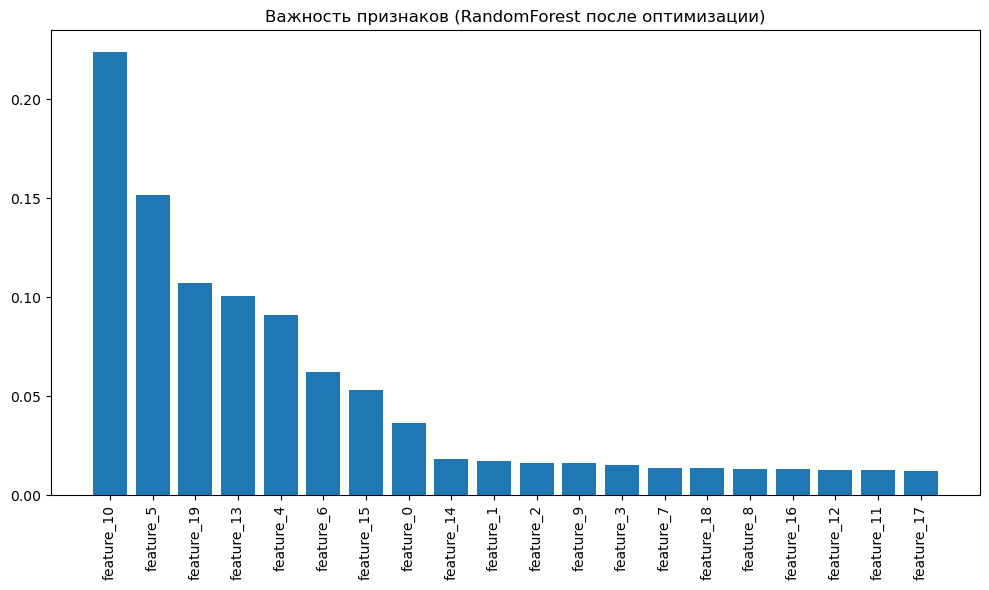

In [39]:
# Визуализация
plt.figure(figsize=(10, 6))
plt.title("Важность признаков (RandomForest после оптимизации)")
plt.bar(range(X.shape[1]), importances[indices], align='center')
plt.xticks(range(X.shape[1]), [f'feature_{i}' for i in indices], rotation=90)
plt.tight_layout()
plt.show()

In [41]:
# Таблица важности
importance_df = pd.DataFrame({
    'Признак': [f'feature_{i}' for i in range(20)],
    'Важность': importances
}).sort_values('Важность', ascending=False)

In [42]:
print("\nТоп-10 наиболее важных признаков:")
print(importance_df.head(10).to_string(index=False))


Топ-10 наиболее важных признаков:
   Признак  Важность
feature_10  0.223728
 feature_5  0.151617
feature_19  0.107165
feature_13  0.100839
 feature_4  0.091110
 feature_6  0.062088
feature_15  0.053096
 feature_0  0.036647
feature_14  0.018470
 feature_1  0.017079


**Вывод по проделанной работе:** в ходе выполнения практической работы был сгенерирован синтетический датасет make_classification с 1000 образцов, 20 признаками (из которых только 5 информативных) для решения задачи бинарной классификации. Проведён первичный анализ данных, выполнено разделение выборки на обучающую и тестовую с сохранением пропорции классов. В качестве базовой модели обучено одиночное дерево решений, затем случайный лес с параметрами по умолчанию. С помощью GridSearchCV подобраны оптимальные гиперпараметры случайного леса.  
Случайный лес после оптимизации демонстрирует наилучшее качество. Построен график важности признаков, на основе которого видно, что модель успешно выделила ~5-7 наиболее значимых признаков, что соответствует реальной структуре датасета и подтверждает способность случайного леса эффективно отсеивать шумовые и избыточные признаки.